In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chanda2322/raw-diabetese-dataset-2000")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Amritansu Aditya\.cache\kagglehub\datasets\chanda2322\raw-diabetese-dataset-2000\versions\1


In [2]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [1]:
%matplotlib inline

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch

%matplotlib inline

In [2]:
df = pd.read_csv('Dataset/versions/1/Rawdiabetes_data-final.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,95.819090,107.943468,40.203595,NaN,15.941732,0.549566,24,1
1,3,113.976244,79.366291,20.601002,NaN,33.983182,2.239694,58,1
2,12,128.609219,80.051501,26.498231,81.870147,33.917055,0.117768,25,0
3,14,57.443471,90.487266,12.139349,135.920061,19.597071,2.060368,64,1
4,10,64.159533,NaN,28.164960,-31.188275,25.525207,1.340682,55,0


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,1801.000000,1800.000000,1800.000000,1800.000000,1801.000000,2000.000000,2000.000000,2000.000000
mean,6.903000,122.532462,69.360160,20.298497,79.238247,30.233085,1.304855,50.031500,0.524500
std,4.357532,37.515323,16.019814,10.038757,40.485558,8.110905,0.684860,17.269761,0.499524
min,0.000000,18.347158,-25.000000,-17.087966,-56.358669,3.681548,0.100578,20.000000,0.000000
25%,3.000000,100.756237,60.162501,13.364605,52.034434,25.059183,0.714062,35.000000,0.000000
50%,7.000000,121.894964,69.750789,20.370017,79.091089,30.227466,1.307738,51.000000,1.000000
75%,11.000000,142.121194,79.458980,27.426832,106.516038,34.842849,1.871716,65.000000,1.000000
max,14.000000,522.000000,124.865527,55.994668,222.224685,99.000000,2.499742,79.000000,1.000000


In [5]:
df.isna().sum()

Pregnancies                   0
Glucose                     199
BloodPressure               200
SkinThickness               200
Insulin                     200
BMI                         199
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [6]:
print(df.std())
df.mean()

Pregnancies                  4.357532
Glucose                     37.515323
BloodPressure               16.019814
SkinThickness               10.038757
Insulin                     40.485558
BMI                          8.110905
DiabetesPedigreeFunction     0.684860
Age                         17.269761
Outcome                      0.499524
dtype: float64


Pregnancies                   6.903000
Glucose                     122.532462
BloodPressure                69.360160
SkinThickness                20.298497
Insulin                      79.238247
BMI                          30.233085
DiabetesPedigreeFunction      1.304855
Age                          50.031500
Outcome                       0.524500
dtype: float64

In [7]:
df['BMI'].fillna(df['BMI'].mean(), inplace = True)

C:\Users\Amritansu Aditya\AppData\Local\Temp\ipykernel_3240\2472434603.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI'].fillna(df['BMI'].mean(), inplace = True)


In [8]:
df.isna().sum()

Pregnancies                   0
Glucose                     199
BloodPressure               200
SkinThickness               200
Insulin                     200
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
df = df.dropna()


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,6.877473,122.679415,68.931313,20.107965,79.338041,30.249618,1.307104,50.465753,0.529680
std,4.422582,36.823605,15.897207,9.958594,40.173843,8.055674,0.670095,17.194266,0.499308
min,0.000000,18.347158,-25.000000,-17.087966,-56.358669,3.681548,0.100578,20.000000,0.000000
25%,3.000000,101.820570,60.131667,13.282067,52.443584,25.432329,0.747432,36.000000,0.000000
50%,7.000000,122.566826,69.160075,20.051481,78.865851,30.233085,1.304031,51.000000,1.000000
75%,11.000000,142.534999,78.628936,27.267019,106.054618,34.296155,1.839846,65.000000,1.000000
max,14.000000,522.000000,113.263484,55.994668,222.224685,97.000000,2.495675,79.000000,1.000000


In [11]:
data = df.to_numpy()
data[:5]

array([[1.20000000e+01, 1.28609219e+02, 8.00515006e+01, 2.64982305e+01,
        8.18701474e+01, 3.39170551e+01, 1.17768301e-01, 2.50000000e+01,
        0.00000000e+00],
       [1.40000000e+01, 5.74434707e+01, 9.04872663e+01, 1.21393490e+01,
        1.35920061e+02, 1.95970713e+01, 2.06036806e+00, 6.40000000e+01,
        1.00000000e+00],
       [7.00000000e+00, 1.11007843e+02, 7.19568117e+01, 1.98741994e+01,
        3.86717495e+01, 2.25834552e+01, 1.44230653e+00, 6.40000000e+01,
        1.00000000e+00],
       [1.20000000e+01, 1.33636904e+02, 5.02101713e+01, 5.88148292e+00,
        7.22311634e+01, 3.60424884e+01, 1.71224311e+00, 2.30000000e+01,
        1.00000000e+00],
       [4.00000000e+00, 1.42321148e+02, 6.08807733e+01, 1.76123728e+01,
        4.01256949e+01, 3.21622194e+01, 1.13546798e+00, 2.90000000e+01,
        0.00000000e+00]])

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,12,128.609219,80.051501,26.498231,81.870147,33.917055,0.117768,25,0
3,14,57.443471,90.487266,12.139349,135.920061,19.597071,2.060368,64,1
5,7,111.007843,71.956812,19.874199,38.671749,22.583455,1.442307,64,1
6,12,133.636904,50.210171,5.881483,72.231163,36.042488,1.712243,23,1
7,4,142.321148,60.880773,17.612373,40.125695,32.162219,1.135468,29,0


In [13]:
target = data[:,-1]
target.shape
data = data[:, :-1]
data[0:5]

array([[1.20000000e+01, 1.28609219e+02, 8.00515006e+01, 2.64982305e+01,
        8.18701474e+01, 3.39170551e+01, 1.17768301e-01, 2.50000000e+01],
       [1.40000000e+01, 5.74434707e+01, 9.04872663e+01, 1.21393490e+01,
        1.35920061e+02, 1.95970713e+01, 2.06036806e+00, 6.40000000e+01],
       [7.00000000e+00, 1.11007843e+02, 7.19568117e+01, 1.98741994e+01,
        3.86717495e+01, 2.25834552e+01, 1.44230653e+00, 6.40000000e+01],
       [1.20000000e+01, 1.33636904e+02, 5.02101713e+01, 5.88148292e+00,
        7.22311634e+01, 3.60424884e+01, 1.71224311e+00, 2.30000000e+01],
       [4.00000000e+00, 1.42321148e+02, 6.08807733e+01, 1.76123728e+01,
        4.01256949e+01, 3.21622194e+01, 1.13546798e+00, 2.90000000e+01]])

In [14]:
np.isinf(target).sum()

np.int64(0)

In [ ]:
fig, ax = plt.subplots(3, 3)
ax = ax.flatten()
for i in range(8):
    axe = ax[i]
    axe.hist(data[:, i])
ax[8].plot(target)
plt.show()

In [ ]:
data = (data - np.mean(data, axis = 0, keepdims = True)) / np.std(data, axis = 0, keepdims = True)
data[0:5]

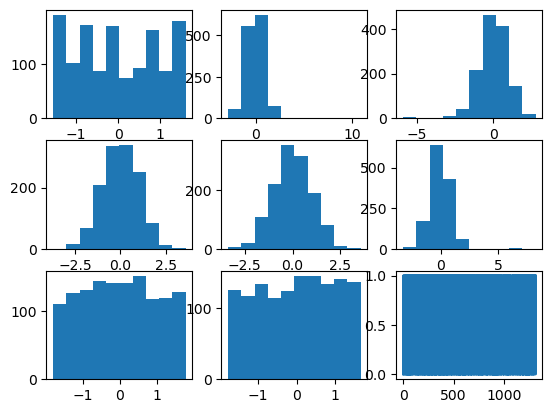

In [62]:
fig, ax = plt.subplots(3, 3)
ax = ax.flatten()
for i in range(8):
    axe = ax[i]
    axe.hist(data[:, i])
ax[8].plot(target)
plt.show()

array([1, 2, 3])

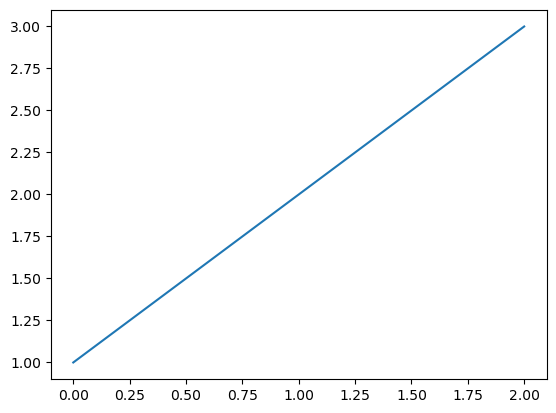